# 04 — Pairs Trading Research (Example)

**Pair**: EWA (Australia) / EWC (Canada) — two commodity-linked developed
markets, chosen for economic reasoning rather than cherry-picked for
historical performance.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from quantlab.config import ExperimentConfig
from quantlab.data.loader import DataLoader
from quantlab.data.base import price_matrix
from quantlab.strategies.pairs_trading import adf_pvalue, rolling_hedge_parameters
from quantlab.features.mean_reversion import rolling_zscore
from quantlab.backtesting.runner import run_backtest_from_config

config = ExperimentConfig.from_yaml("../configs/pairs_trading.yaml")
data, report = DataLoader().load(config)
prices = price_matrix(data)
a, b = prices["EWA"].dropna(), prices["EWC"].dropna()
common_idx = a.index.intersection(b.index)
a, b = a.loc[common_idx], b.loc[common_idx]
print(report.summary())
print(f"Correlation of daily returns: {a.pct_change().corr(b.pct_change()):.3f}")


DataQualityReport(rows=12072/12072 clean/raw, duplicates=0, invalid_prices=0, missing_values=0, gaps=0, warnings=0)
Correlation of daily returns: 0.826


## Hedge ratio and spread

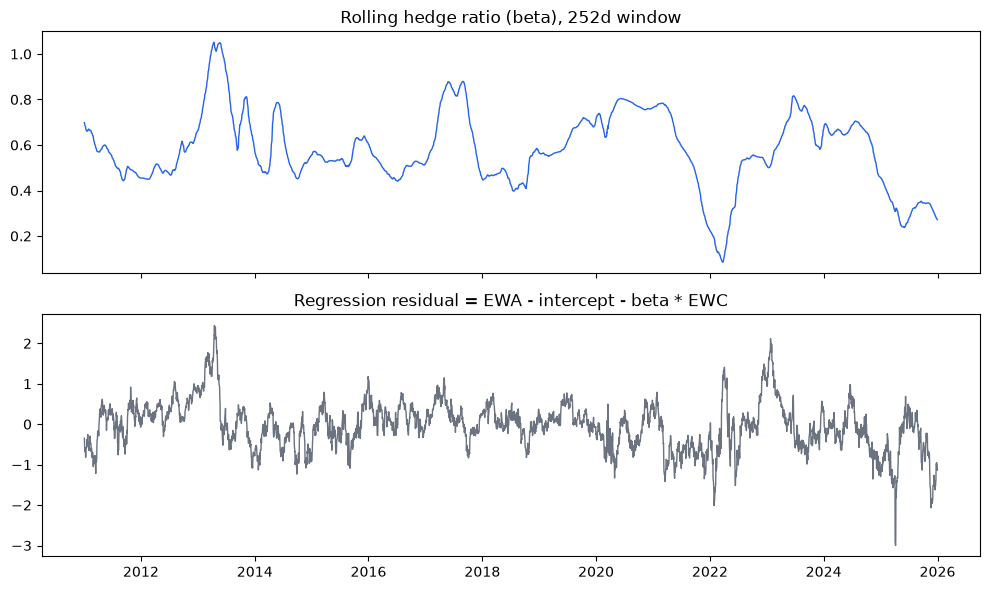

In [2]:
intercept, beta = rolling_hedge_parameters(a, b, window=252, dynamic=True)
spread = a - intercept - beta * b

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(beta.index, beta.to_numpy(dtype=float), color="#2563eb", lw=1.0)
axes[0].set_title("Rolling hedge ratio (beta), 252d window")
axes[1].plot(spread.index, spread.to_numpy(dtype=float), color="#6b7280", lw=1.0)
axes[1].set_title("Regression residual = EWA - intercept - beta * EWC")
plt.tight_layout()
plt.show()


## Stationarity of the spread (Augmented Dickey-Fuller)

The Augmented Dickey-Fuller test evaluates whether the spread behaves like a
non-stationary unit-root process or tends to remain around a more stable
long-term level.

- **Null hypothesis (H0):** the spread has a unit root and is non-stationary;
  deviations may persist indefinitely.
- **Alternative hypothesis (H1):** the spread is stationary; deviations are
  more consistent with mean-reverting behaviour.

A low p-value provides evidence against the unit-root hypothesis. For example,
a p-value below 0.05 allows H0 to be rejected at the conventional 5% level.
It does not represent the probability that the spread is stationary and does
not prove that a trading strategy will be profitable.

The test below uses all available regression residuals and is therefore
descriptive rather than a tradable signal. During the backtest, QuantLab
periodically recomputes the regression and ADF test on exactly the preceding
formation window. The result acts as an entry gate: a new position is
permitted only when the residual passes the configured stationarity threshold
and the z-score entry condition is also satisfied.


In [3]:
pvalue_full_sample = adf_pvalue(spread.dropna())
if pvalue_full_sample is None:
    print("ADF test inconclusive on the full-sample regression residual.")
else:
    print(f"ADF p-value on the full-sample residual: {pvalue_full_sample:.2e}")
    print("(A low value is evidence against the unit-root null.)")


ADF p-value on the full-sample residual: 3.01e-08
(A low value is evidence against the unit-root null.)


In [4]:
# The rolling regression above re-estimates the hedge ratio every day, which
# absorbs any drift in the true EWA/EWC relationship into a time-varying beta
# instead of leaving it in the residual — this alone can make the residual
# look far more stationary than it really is. Comparing against a *single*
# hedge ratio fixed over the whole sample shows how much of the result above
# comes from that adaptivity rather than genuine long-run cointegration.
from quantlab.strategies.pairs_trading import _ols_coefficients

static_intercept, static_beta = _ols_coefficients(
    b.to_numpy(dtype=float), a.to_numpy(dtype=float)
)
static_spread = a - static_intercept - static_beta * b
pvalue_static = adf_pvalue(static_spread.dropna())

print(f"Rolling-hedge-ratio spread ADF p-value: {pvalue_full_sample:.2e}")
if pvalue_static is None:
    print("Static (single, full-sample) hedge-ratio spread: ADF test inconclusive.")
else:
    print(f"Static (single, full-sample) hedge-ratio spread ADF p-value: {pvalue_static:.4f}")


Rolling-hedge-ratio spread ADF p-value: 3.01e-08
Static (single, full-sample) hedge-ratio spread ADF p-value: 0.4758


The two p-values above can differ by orders of magnitude, and that is
expected, not a bug. The rolling regression re-fits its hedge ratio to the
*current* relationship every day, so any long-run drift between EWA and EWC
is absorbed into the time-varying beta rather than left in the residual —
which makes a rolling-hedge spread mechanically look more stationary than a
spread built from one hedge ratio fixed over the whole sample. Neither number
is "the" answer to "is this pair cointegrated": the rolling version matches
what `dynamic_hedge_ratio: true` does during the backtest (see
`configs/pairs_trading.yaml`), while the static version is the more
conservative, classical full-sample cointegration test. Read a very small
rolling-spread p-value as "this hedge ratio tracks the relationship well,"
not as strong standalone evidence that the pair is permanently stationary.


## Spread z-score and trading thresholds

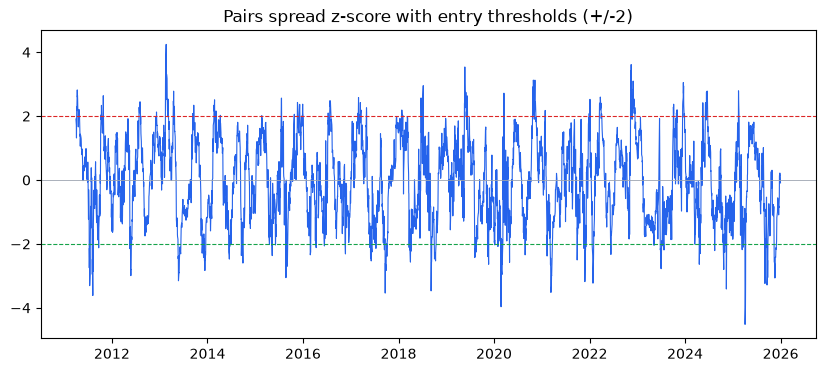

In [5]:
z = rolling_zscore(spread, window=config.strategy.parameters["zscore_window"])
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(z.index, z.to_numpy(dtype=float), color="#2563eb", lw=0.8)
ax.axhline(2, color="#dc2626", lw=0.8, ls="--")
ax.axhline(-2, color="#16a34a", lw=0.8, ls="--")
ax.axhline(0, color="#9ca3af", lw=0.6)
ax.set_title("Pairs spread z-score with entry thresholds (+/-2)")
plt.show()


## Full backtest

In [6]:
result = run_backtest_from_config(data, config, data_quality_report=report)
print(result.summary())


Experiment : pairs_trading_ewa_ewc
Strategy   : pairs_trading
Symbols    : EWA, EWC
Period     : 2010-01-04 -> 2025-12-31
------------------------------------------------
Total return       :     15.25%
CAGR               :      0.89%
Volatility (ann.)  :      3.05%
Sharpe             :      -0.35
Sortino            :      -0.57
Calmar             :       0.11
Max drawdown       :     -8.01%
Hit rate (non-zero periods): 47.95%
Total costs (currency units): 4615.59
Number of trades   :       1314
------------------------------------------------
Beta               :      -0.01
Alpha (ann.)       :     -0.97%
Information ratio  :      -0.77


## Takeaways

The spread exhibits periods of mean-reverting behaviour, but the strategy
produces a negative net Sharpe ratio after transaction costs. Under the tested
rules, period and execution assumptions, the results therefore provide no
evidence of a profitable trading edge. This remains an honest and useful
research finding: statistical mean reversion does not necessarily translate
into an economically viable strategy after costs.
